# Cluster maps

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyccl as ccl

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *
from fitMap import *
from cluster import *

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Power spectrum

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


Saving Cl_ell in Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_Cl_ell.pdf


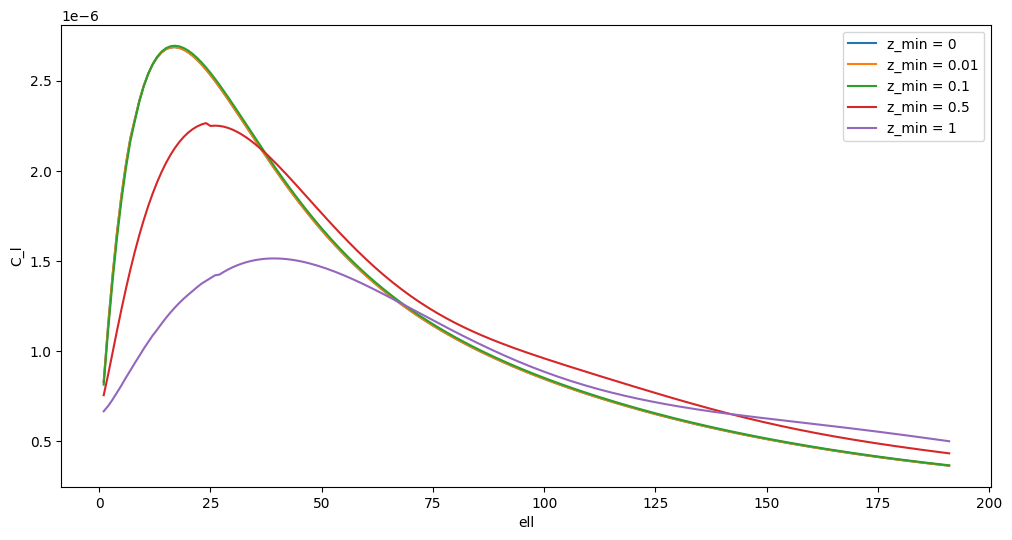

In [5]:
lmin = 1
zmin = [0, 0.01, 0.1, 0.5, 1]
plt.figure(figsize=(12, 6))
for zm in zmin:
    cl, ell = get_Cl_ccl(nside, zm, get_ell=True)
    plt.plot(ell[lmin:], cl[lmin:], label = f"z_min = {zm}")
plt.xlabel('ell')
plt.ylabel('C_l')
plt.legend();

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_"
get_savefig(plt, output_path, "Cl_ell")

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


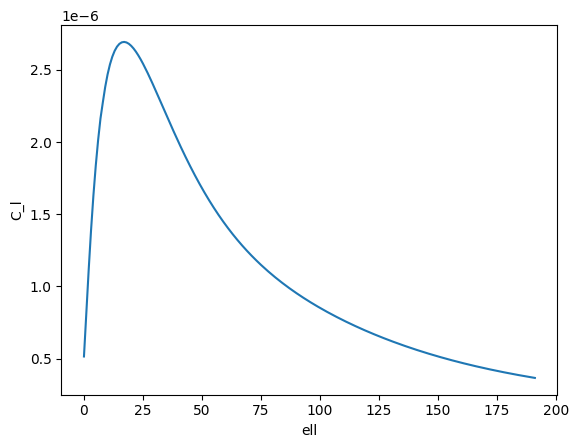

In [3]:
cl, ell = get_Cl_ccl(nside, get_ell=True)
plt.plot(ell, cl)
plt.xlabel('ell')
plt.ylabel('C_l');

## Cluster map

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1871 (χ²/ndof = 0.0)       │             Nfcn = 1157              │
│ EDM = 5.7e-06 (Goal: 0.0002)     │           time = 15.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  2.0e-6   │ 1561.3e-6 │  -2.0e-6   │  321.0e-6  │    0    │         │       │
│ 1 │ A    │  0.06e-6  │11088.04e-6│  -0.06e-6  │ 597.42e-6  │    0    │    1    │       │
│ 2 │ l    │    29     │    243    │    -29     │    331     │    0    │   360   │       │
│ 3 │ b    │  0.04e3   │  0.15e3   │  -0.15e3   │   0.15e3   │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2e-6   │  321e-6   │ -0.06e-6  │ 597.42e-6 │    -29    │    331    │  -0.15e3  │  0.15e3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   False   │   False   │
│ At Limit │   True    │   False   │   True    │   False   │   True    │   True    │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────────────┐
│   │            M            A            l            b │
├───┼─────────────────────────────────────────────────────┤
│ M │     1.24e-08           -0    -1.641e-6     5.865e-6 │
│ A │           -0     2.76e-09  110.7854e-6 -362.8203e-6 │
│ l │    -1.641e-6  110.7854e-6     3.79e+04           -0 │
│ b │     5.865e-6 -362.8203e-6           -0     2.69e+04 │
└───┴─────────────────────────────────────────────────────┘

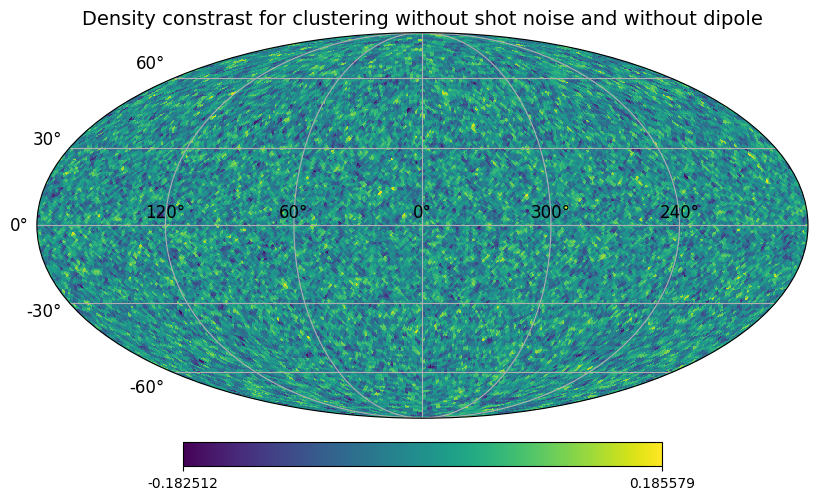

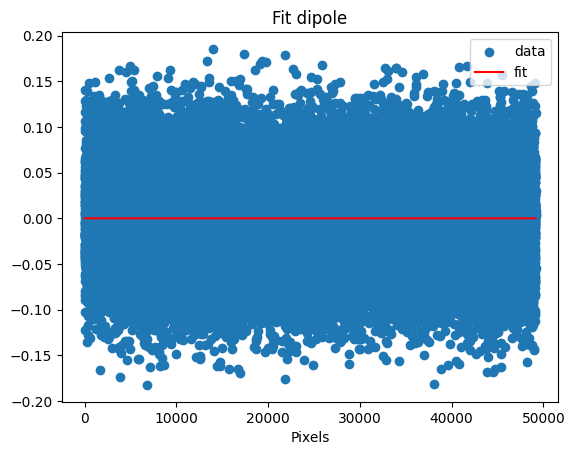

In [46]:
nest=False
lognormal=False
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)

title="Density constrast for clustering without shot noise and without dipole"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (1000, 0, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))

output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
#get_saveFit_minuit(m, output_path, sufix, np.arange(0, npix), NSource_px_Cl, np.sqrt(np.abs(NSource_px_Cl)))
m

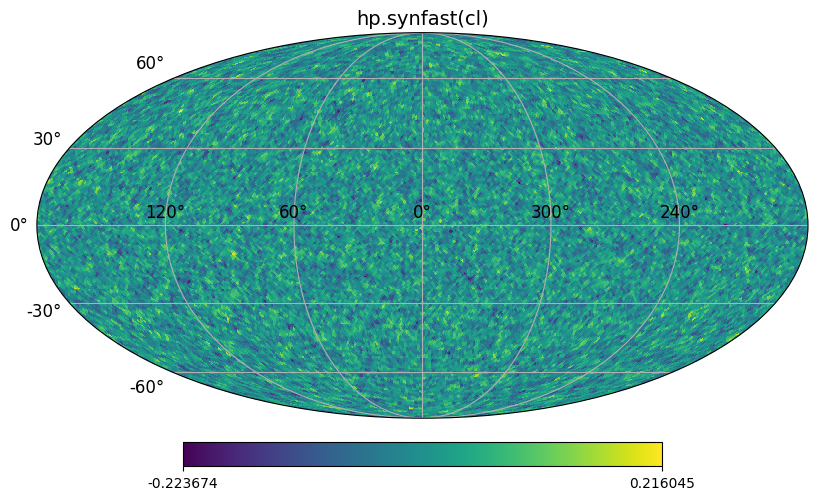

In [17]:
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)

title="hp.synfast(cl)"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True);

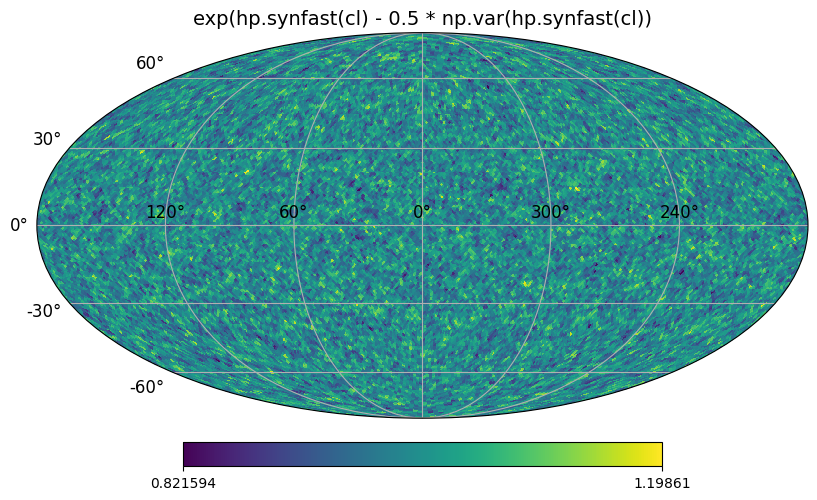

In [6]:
NSource_px_Cl = np.exp(NSource_px_Cl - 0.5 * np.var(NSource_px_Cl))

title="exp(hp.synfast(cl) - 0.5 * np.var(hp.synfast(cl))"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

## Adding dipole

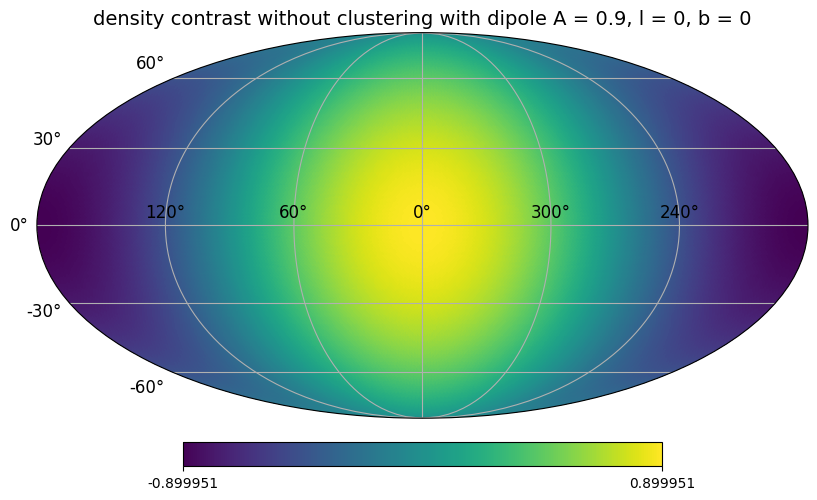

In [20]:
NSource_px_dipole = apply_dipole_MD(NSource_px_Cl, 0, A, l, b, nest)
hp.projview(NSource_px_dipole, title=f"density contrast without clustering with dipole A = {A}, l = {l}, b = {b}", graticule=True, graticule_labels=True)
cl_dipole, alm_dipole = hp.anafast(NSource_px_dipole, alm=True)

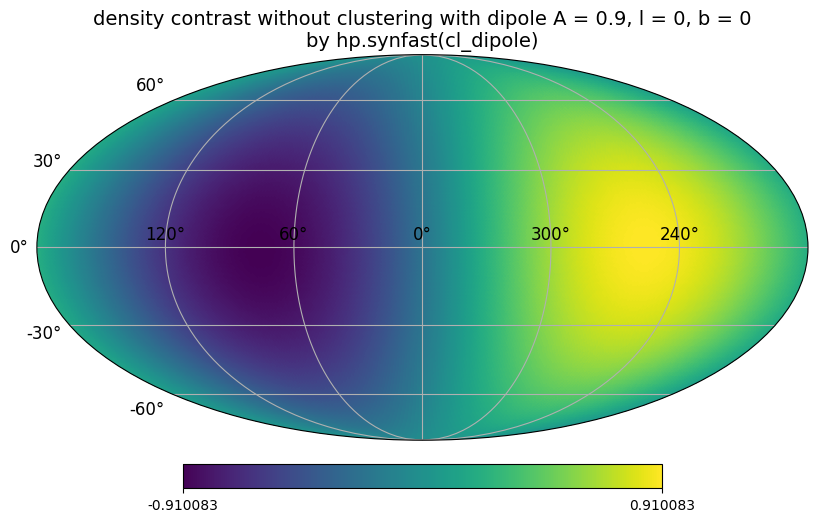

In [19]:
NSource_px_dipole = hp.synfast(cl_dipole, nside=nside)
hp.projview(NSource_px_dipole, title=f"density contrast without clustering with dipole A = {A}, l = {l}, b = {b}\nby hp.synfast(cl_dipole)", graticule=True, graticule_labels=True);

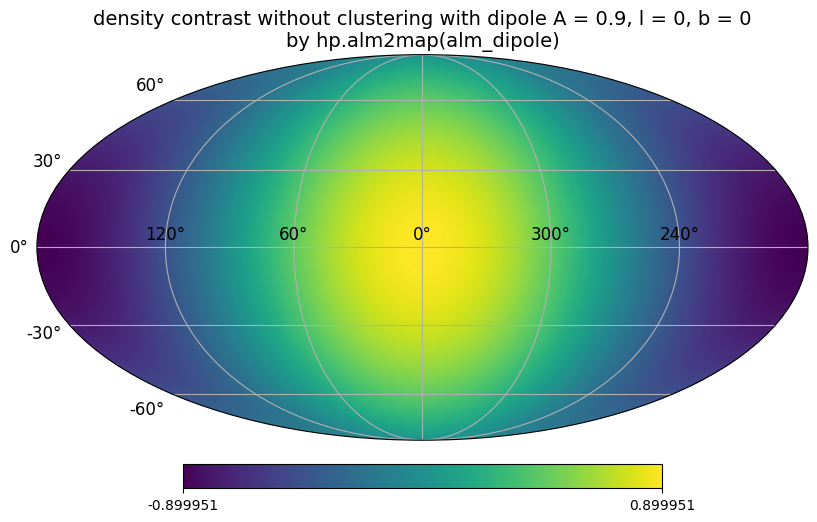

In [21]:
NSource_px_dipole = hp.alm2map(alm_dipole, nside=nside)
hp.projview(NSource_px_dipole, title=f"density contrast without clustering with dipole A = {A}, l = {l}, b = {b}\nby hp.alm2map(alm_dipole)", graticule=True, graticule_labels=True);

(0.9999999999999999, 0.9999990463259868, 20.0, 40.0) -> 787167.5313922997
(1.0043337388975166, 0.9999990463259868, 20.0, 40.0) -> 792630.2159653135
(0.9956693890774038, 0.9999990463259868, 20.0, 40.0) -> 781731.7276137271
(1.0005119442882946, 0.9999990463259868, 20.0, 40.0) -> 787811.641878884
(0.9994880993891413, 0.9999990463259868, 20.0, 40.0) -> 786523.7962571405
(0.9999999999999999, 0.9986668653211442, 20.0, 40.0) -> 786758.134703158
(0.9999999999999999, 0.9985205308068257, 20.0, 40.0) -> 786713.1974725677
(0.9999999999999999, 0.9999923098407952, 20.0, 40.0) -> 787165.4598084745
(0.9999999999999999, 0.9999776628011343, 20.0, 40.0) -> 787160.9556427264
(0.9999999999999999, 0.9999990463259868, 20.08673243307266, 40.0) -> 787230.0409930315
(0.9999999999999999, 0.9999990463259868, 19.913444207030707, 40.0) -> 787105.7646841105
(0.9999999999999999, 0.9999990463259868, 20.061632469235647, 40.0) -> 787211.8875776917
(0.9999999999999999, 0.9999990463259868, 19.938456779309675, 40.0) -> 787

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1322 (χ²/ndof = 0.0)       │              Nfcn = 585              │
│ EDM = 4.2e-07 (Goal: 0.0002)     │            time = 6.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  0.5e-3   │  1.3e-3   │  -0.5e-3   │   1.3e-3   │    0    │         │       │
│ 1 │ A    │   0.852   │   0.006   │   -0.006   │   0.006    │    0    │    1    │       │
│ 2 │ l    │  0.6e-12  │45187564329.8e-12│  -0.6e-12  │40844724896.6e-12│    0    │   360   │       │
│ 3 │ b    │   0.08    │   0.12    │   -0.12    │    0.12    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.5e-3  │  1.3e-3   │  -0.006   │   0.006   │ -0.6e-12  │40844724896.6e-12│   -0.12   │   0.12    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   False   │   False   │   True    │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────┐
│   │          M          A          l          b │
├───┼─────────────────────────────────────────────┤
│ M │   1.65e-06          0  -0.12e-12   -12.8e-6 │
│ A │          0   3.47e-05   0.24e-12         -0 │
│ l │  -0.12e-12   0.24e-12   1.02e-13 -24.33e-12 │
│ b │   -12.8e-6         -0 -24.33e-12     0.0143 │
└───┴─────────────────────────────────────────────┘

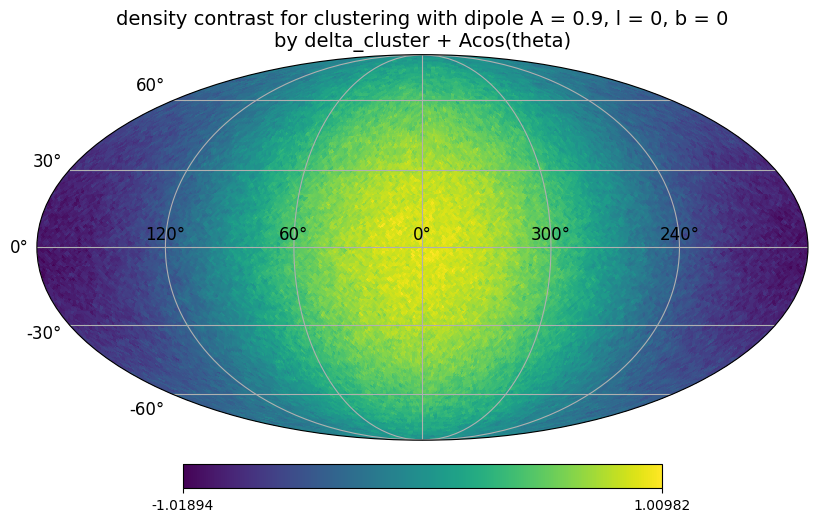

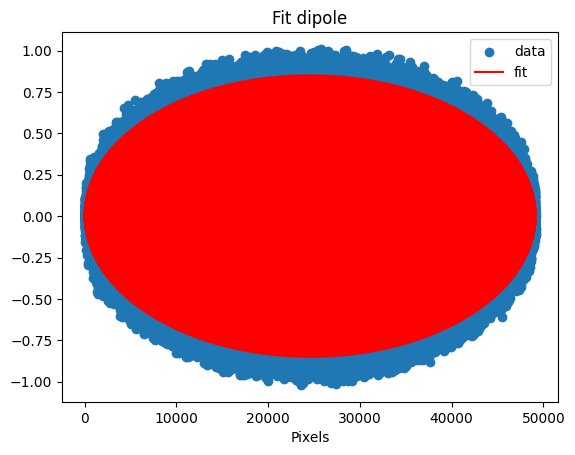

In [5]:
lognormal=False
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)
alm_Cl = hp.map2alm(NSource_px_Cl)

A, l, b = 0.9, 0, 0
NSource_px_dipole = apply_dipole_MD(NSource_px_Cl, NSource_px_Cl, A, l, b, nest)
title=f"density contrast for clustering with dipole A = {A}, l = {l}, b = {b}\nby delta_cluster + Acos(theta)"
hp.projview(NSource_px_dipole, title=title, graticule=True, graticule_labels=True);

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='galactic')
init =  (1, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_dipole, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6666 (χ²/ndof = 0.1)       │              Nfcn = 519              │
│ EDM = 1.28e-08 (Goal: 0.0002)    │            time = 6.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  0.0047   │  0.0014   │  -0.0014   │   0.0014   │    0    │         │       │
│ 1 │ A    │   0.842   │   0.006   │   -0.006   │   0.006    │    0    │    1    │       │
│ 2 │ l    │ 0.025e-12 │1811815986.264e-12│ -0.025e-12 │1811814558.775e-12│    0    │   360   │       │
│ 3 │ b    │  -56.31   │   0.15    │   -0.14    │    0.15    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.0014  │  0.0014   │  -0.006   │   0.006   │-0.025e-12 │1811814558.775e-12│   -0.14   │   0.15    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────┐
│   │          M          A          l          b │
├───┼─────────────────────────────────────────────┤
│ M │   2.03e-06     0.2e-6  -0.03e-15    23.7e-6 │
│ A │     0.2e-6   3.48e-05  -4.18e-15  -0.009e-3 │
│ l │  -0.03e-15  -4.18e-15   1.83e-16 -42.67e-15 │
│ b │    23.7e-6  -0.009e-3 -42.67e-15     0.0211 │
└───┴─────────────────────────────────────────────┘

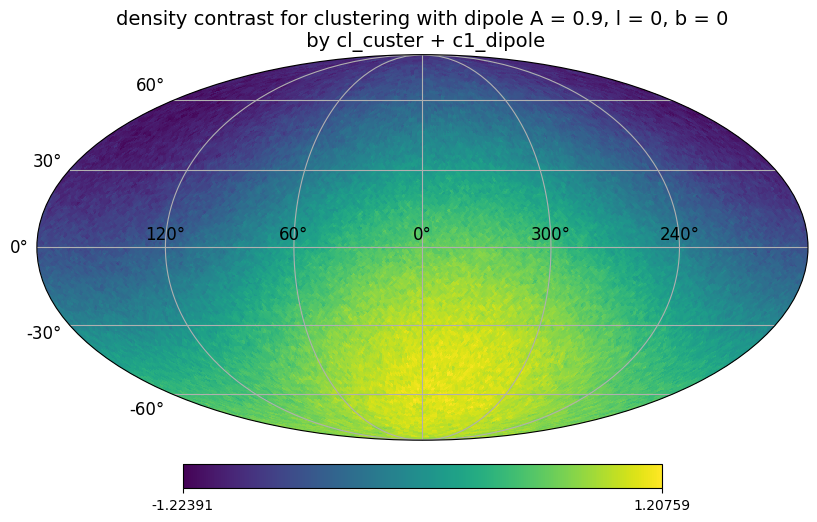

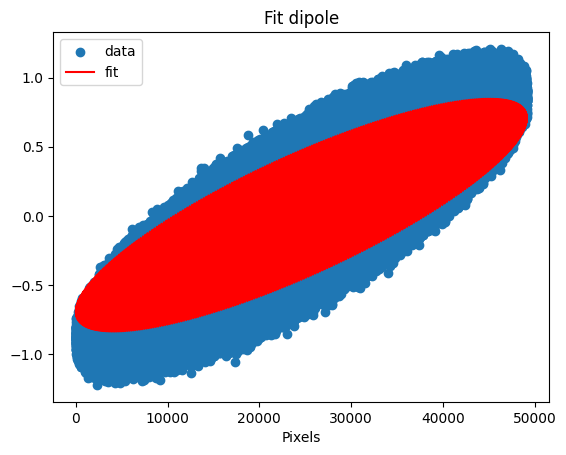

In [13]:
cl_new = cl.copy()
cl_new[1] += cl_dipole[1]
NSource_px_dipole = get_clusterContrast(cl_new, nside, lognormal=lognormal)

title=f"density contrast for clustering with dipole A = {A}, l = {l}, b = {b}\n by cl_custer + c1_dipole"
hp.projview(NSource_px_dipole, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (1000, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_dipole, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1689 (χ²/ndof = 0.0)       │              Nfcn = 650              │
│ EDM = 1.32e-06 (Goal: 0.0002)    │            time = 5.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │ 0.027e-9  │556348.717e-9│ -0.027e-9  │469016.546e-9│    0    │         │       │
│ 1 │ A    │   0.836   │   0.006   │   -0.006   │   0.006    │    0    │    1    │       │
│ 2 │ l    │  359.31   │   0.11    │   -0.11    │    0.11    │    0    │   360   │       │
│ 3 │ b    │   -0.67   │   0.13    │   -0.13    │    0.13    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.027e-9 │469016.546e-9│  -0.006   │   0.006   │   -0.11   │   0.11    │   -0.13   │   0.13    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────┐
│   │         M         A         l         b │
├───┼─────────────────────────────────────────┤
│ M │  5.91e-14 -0.03e-12 -0.31e-12 -6.55e-12 │
│ A │ -0.03e-12  3.41e-05 -0.002e-3 -0.001e-3 │
│ l │ -0.31e-12 -0.002e-3    0.0119    -0.001 │
│ b │ -6.55e-12 -0.001e-3    -0.001    0.0158 │
└───┴─────────────────────────────────────────┘

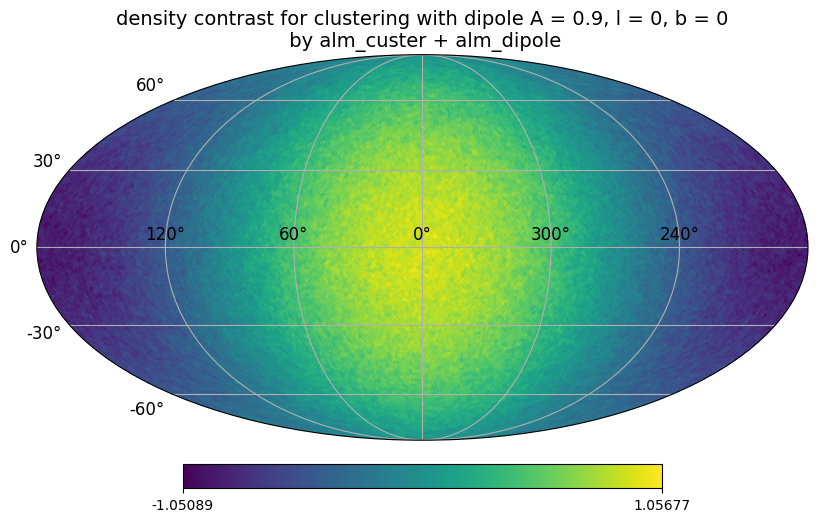

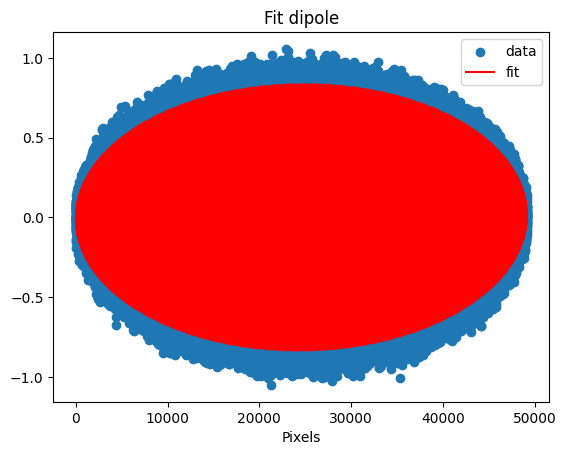

In [23]:
NSource_px_dipole = hp.alm2map(alm_dipole+alm_Cl, nside=nside)

title=f"density contrast for clustering with dipole A = {A}, l = {l}, b = {b}\n by alm_custer + alm_dipole"
hp.projview(NSource_px_dipole, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (1000, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_dipole, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1686 (χ²/ndof = 0.0)       │              Nfcn = 778              │
│ EDM = 8.27e-06 (Goal: 0.0002)    │            time = 6.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  0.9e-9   │567629.1e-9│  -0.9e-9   │476433.7e-9 │    0    │         │       │
│ 1 │ A    │   0.836   │   0.006   │   -0.006   │   0.006    │    0    │    1    │       │
│ 2 │ l    │  359.33   │   0.11    │   -0.11    │    0.11    │    0    │   360   │       │
│ 3 │ b    │   -0.67   │   0.13    │   -0.13    │    0.13    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.9e-9  │476433.7e-9│  -0.006   │   0.006   │   -0.11   │   0.11    │   -0.13   │   0.13    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────┐
│   │         M         A         l         b │
├───┼─────────────────────────────────────────┤
│ M │  2.09e-12  -0.2e-12  -2.5e-12 -50.7e-12 │
│ A │  -0.2e-12  3.41e-05 -0.002e-3 -0.001e-3 │
│ l │  -2.5e-12 -0.002e-3     0.012    -0.001 │
│ b │ -50.7e-12 -0.001e-3    -0.001    0.0162 │
└───┴─────────────────────────────────────────┘

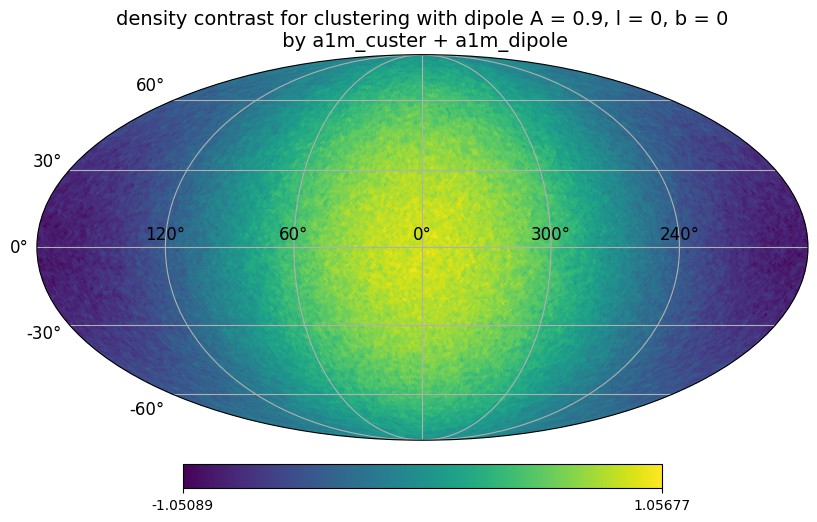

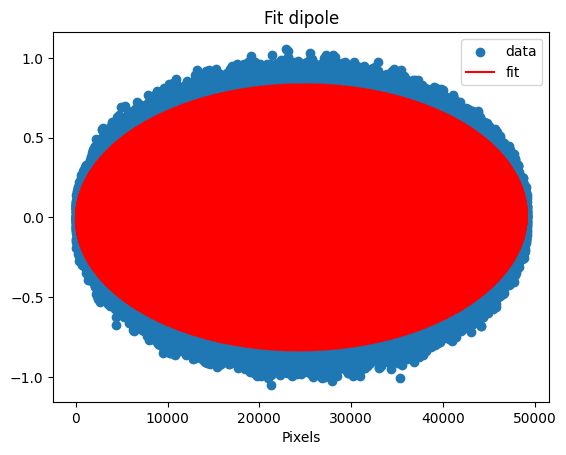

In [27]:
lmax = hp.Alm.getlmax(len(alm_dipole)) # Pour retrouver le lmax du tableau
idx_10 = hp.Alm.getidx(lmax, l=1, m=0) # Indice pour l=1, m=0
idx_11 = hp.Alm.getidx(lmax, l=1, m=1) # Indice pour l=1, m=1

alm_new = alm_Cl.copy()
alm_new[idx_10] += alm_dipole[idx_10]
alm_new[idx_11] += alm_dipole[idx_11]

NSource_px_dipole = hp.alm2map(alm_new, nside=nside)

title=f"density contrast for clustering with dipole A = {A}, l = {l}, b = {b}\n by a1m_custer + a1m_dipole"
hp.projview(NSource_px_dipole, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (1000, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_dipole, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

## Count map

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.431e+08 (χ²/ndof = 4946.5)│              Nfcn = 501              │
│ EDM = 2.04e-07 (Goal: 0.0002)    │            time = 9.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │ 995.197e3 │  0.004e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │ 919.450e3 │  0.006e3  │  -0.006e3  │  0.006e3   │    0    │         │       │
│ 2 │ l    │ 359.9597  │  0.0004   │  -0.0004   │   0.0004   │    0    │   360   │       │
│ 3 │ b    │  -2.5e-3  │  0.4e-3   │  -0.4e-3   │   0.4e-3   │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │    -6     │     6     │  -0.4e-3  │  0.4e-3   │  -0.4e-3  │  0.4e-3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────┐
│   │         M         A         l         b │
├───┼─────────────────────────────────────────┤
│ M │      20.2        19   0.03e-6         0 │
│ A │        19      38.8  20.33e-6 -13.86e-6 │
│ l │   0.03e-6  20.33e-6  1.83e-07         0 │
│ b │         0 -13.86e-6         0  1.82e-07 │
└───┴─────────────────────────────────────────┘

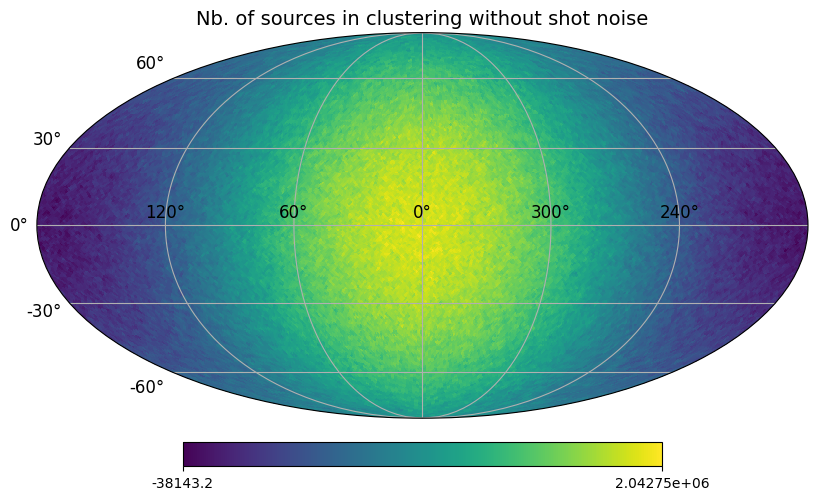

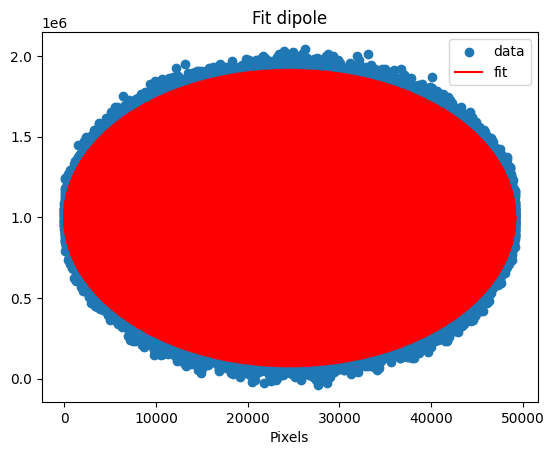

In [9]:
counts = NSource_px_th*(1 + NSource_px_dipole)
title="Nb. of sources in clustering without shot noise"
hp.projview(counts, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (1000, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, counts, init, names, bounds=([0, 0, 0, -90], [np.inf, np.inf, 360, 90]))
m

## Including shot noise

In [ ]:
def shotNoise_negBin(mu, alpha):
    var = mu + alpha * mu**2
    p = mu / var
    r = mu**2 / (var - mu)
    return np.random.negative_binomial(r, 1-p)


def sample_counts(delta, Nbar, mode="poisson", alpha=1.0, lognormal=False):
    if lognormal: mu = Nbar * delta
    else: mu = Nbar * (1 + delta)

    if mode == "poisson":
        return np.random.poisson(mu)

    elif mode == "negbin":
        return shotNoise_negBin(mu, alpha)
    
    else: return mu

## Fitting map

Cl[ℓ=1] = 6.924730511332348e-07

=== RESULTS ===
zmin: 0.0
Clustering: False
Noise: poisson
True dipole: [0, 0, 0.01]
Mean: [-1.16659962e-08  1.99407985e-06 -2.04071591e-06]
Std : [1.18844847e-05 1.21676538e-05 8.29944765e-06]
Amplitude: 1.749822971524837e-05


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.925e+04 (χ²/ndof = 1.0)  │              Nfcn = 814              │
│ EDM = 8.6e-07 (Goal: 0.0002)     │            time = 6.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │ 999.998e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A    │    11     │     8     │     -8     │     8      │    0    │         │       │
│ 2 │ l    │    190    │    70     │    -190    │    170     │    0    │   360   │       │
│ 3 │ b    │    -55    │    38     │    -35     │     45     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │    -8     │     8     │  -0.19e3  │  0.17e3   │    -35    │    45     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   True    │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────┐
│   │        M        A        l        b │
├───┼─────────────────────────────────────┤
│ M │     20.3        0       -0        0 │
│ A │        0       61       -0        0 │
│ l │       -0       -0 4.87e+03       -0 │
│ b │        0        0       -0 1.64e+03 │
└───┴─────────────────────────────────────┘

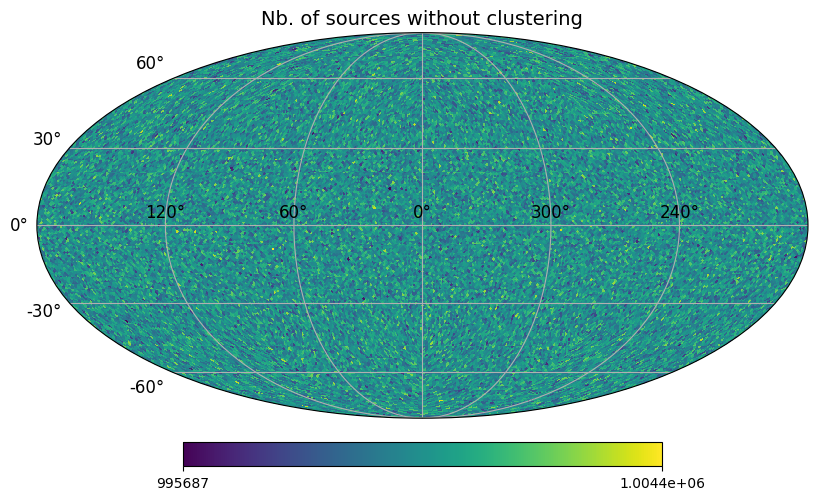

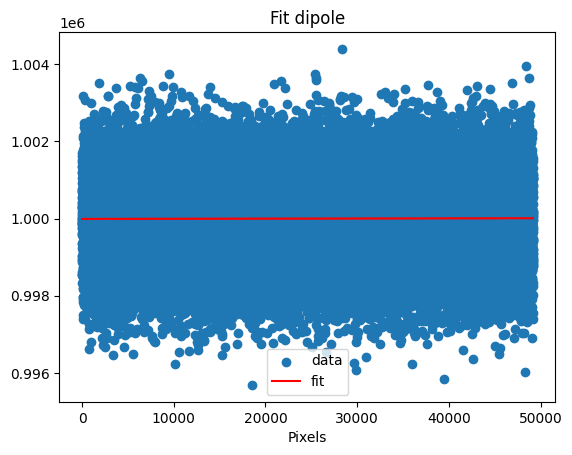

In [31]:
# =========================
# 7. Estimateur MLE
# =========================
def estimate_dipole_mle(counts, mask, nside):
    npix = len(counts)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    n_hat = np.vstack([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)
    ]).T

    w = mask
    y = counts / np.mean(counts) - 1

    A = (n_hat.T * w) @ n_hat
    b = (n_hat.T * w) @ y

    d = np.linalg.solve(A, b)

    return d

# =========================
# 8. Masque simple (sud + plan galactique)
# =========================
def build_mask(nside):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    # hémisphère sud
    mask = (theta > np.pi/2).astype(float)

    # retirer plan galactique |b| < 5°
    b = np.pi/2 - theta
    mask[np.abs(b) < np.deg2rad(5)] = 0.

    return mask

# =========================
# 9. Monte Carlo
# =========================
def run_monte_carlo(Nbar=1e4,
    nsim=50,
    nside=64,
    dipole_amp=0.01,
    zmin=0.0,
    use_clustering=True,
    noise_model="poisson", lognormal=False
):

    cl = compute_cl(nside, zmin)
    mask = build_mask(nside)

    results = []

    for _ in range(nsim):

        m = simulate_map(cl, nside, use_clustering, lognormal=lognormal)

        #m = inject_dipole(m, nside, dipole_amp)
        #m = apply_dipole_MD(m, m, dipole_amp, 0, 0, nest=False)

        counts = sample_counts(m, Nbar=Nbar, mode=noise_model, lognormal=lognormal)
        counts = apply_dipole_MD(counts, counts, dipole_amp, 0, 0, nest=False)

        d = estimate_dipole_mle(counts, mask, nside)

        results.append(d)

    results = np.array(results)

    print("\n=== RESULTS ===")
    print("zmin:", zmin)
    print("Clustering:", use_clustering)
    print("Noise:", noise_model)
    print("True dipole:", [0,0,dipole_amp])

    print("Mean:", np.mean(results, axis=0))
    print("Std :", np.std(results, axis=0))
    print("Amplitude:", np.mean(np.linalg.norm(results, axis=1)))

    return results, m, counts

# sans clustering
_, _, NSource_px_Cl = run_monte_carlo(zmin=0.0, use_clustering=False, lognormal=False, Nbar=NSource_px_th)
title="Nb. of sources without clustering"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (1000, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl, init, names, bounds=([0, 0, 0, -90], [np.inf, np.inf, 360, 90]))
m

In [33]:
dic = m.values.to_dict()
m.errors.to_dict()

{'M': 0.024365851422705587,
 'A': 0.006053410238781531,
 'l': 0.09940093459495711,
 'b': 0.1400795442572627}

In [37]:
for k, v in m.errors.to_dict().items(): print(f'{k} : {v}')

M : 0.024365851422705587
A : 0.006053410238781531
l : 0.09940093459495711
b : 0.1400795442572627
